#           --------      Cardiovascular Disease Analysis     --------

# Data Loading

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
df=pd.read_csv("C:/Users/unifi/OneDrive/Documents/Cardio_Project/final_clean.csv")
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,...,alco_label,active_label,bp_category,bp_risk,age_risk,chol_risk,bmi_risk,activity_risk,risk_score,risk_segmentation
0,0,18393,2,168,62.0,110,80,1,1,0,...,No Alcohol,Active,Normal,0,1,0,0,0,1,Low
1,1,20228,1,156,85.0,140,90,3,1,0,...,No Alcohol,Active,Stage 1,1,1,1,1,0,4,Critical
2,2,18857,1,165,64.0,130,70,3,1,0,...,No Alcohol,Inactive,Elevated,0,1,1,0,1,3,High
3,3,17623,2,169,82.0,150,100,1,1,0,...,No Alcohol,Active,Stage 1,1,1,0,0,0,2,Medium
4,4,17474,1,156,56.0,100,60,1,1,0,...,No Alcohol,Inactive,Normal,0,1,0,0,1,2,Medium


In [2]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 68640 entries, 0 to 68639
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 68640 non-null  int64  
 1   age                68640 non-null  int64  
 2   gender             68640 non-null  int64  
 3   height             68640 non-null  int64  
 4   weight             68640 non-null  float64
 5   ap_hi              68640 non-null  int64  
 6   ap_lo              68640 non-null  int64  
 7   cholesterol        68640 non-null  int64  
 8   gluc               68640 non-null  int64  
 9   smoke              68640 non-null  int64  
 10  alco               68640 non-null  int64  
 11  active             68640 non-null  int64  
 12  cardio             68640 non-null  int64  
 13  BMI                68640 non-null  float64
 14  age_years          68640 non-null  float64
 15  age_group          68640 non-null  str    
 16  bmi_category       68640 non-null

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,...,active,cardio,BMI,age_years,bp_risk,age_risk,chol_risk,bmi_risk,activity_risk,risk_score
count,68640.000000,68640.000000,68640.000000,68640.000000,68640.000000,68640.000000,68640.000000,68640.000000,68640.000000,68640.000000,...,68640.000000,68640.000000,68640.000000,68640.000000,68640.000000,68640.0,68640.000000,68640.000000,68640.000000,68640.000000
mean,49975.832751,19464.710315,1.348616,164.395790,74.119433,126.676005,81.307882,1.364744,1.225801,0.087952,...,0.803365,0.494741,27.473011,53.291492,0.269085,1.0,0.250117,0.261568,0.196635,1.977404
std,28846.470374,2468.085615,0.476536,7.983654,14.306778,16.695471,9.454697,0.678945,0.571665,0.283227,...,0.397457,0.499976,5.351551,6.757257,0.443488,0.0,0.433083,0.439492,0.397457,0.970372
min,0.000000,10798.000000,1.000000,100.000000,30.000000,60.000000,40.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,10.726644,29.560000,0.000000,1.0,0.000000,0.000000,0.000000,1.000000
25%,25001.500000,17658.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,...,1.000000,0.000000,23.875115,48.340000,0.000000,1.0,0.000000,0.000000,0.000000,1.000000
50%,50019.500000,19701.500000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,...,1.000000,0.000000,26.346494,53.940000,0.000000,1.0,0.000000,0.000000,0.000000,2.000000
75%,74870.750000,21324.250000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,...,1.000000,1.000000,30.119376,58.380000,1.000000,1.0,1.000000,1.000000,0.000000,3.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,240.000000,182.000000,3.000000,3.000000,1.000000,...,1.000000,1.000000,152.551775,64.920000,1.000000,1.0,1.000000,1.000000,1.000000,5.000000


## Data Cleaning

### 📌 BMI Outlier Handling

While exploring the dataset using `.describe()`, extreme BMI values were observed (e.g., BMI > 100).

On investigating in Excel, the root cause was identified:
* Height and weight were already cleaned using valid ranges
* However, some **extreme combinations** (e.g., very low height + high weight) produced unrealistic BMI values
Since BMI is derived from height and weight, these cases distort the analysis.

To improve data quality further, **IQR-based outlier removal** is applied on BMI in Python as a final refinement step.


In [3]:
Q1= df["BMI"].quantile(0.25)
Q3= df["BMI"].quantile(0.75)

IQR = Q3-Q1

lower = Q1-(1.5*IQR)
upper = Q3+(1.5*IQR)


print(lower)
print(upper)

df=df[(df["BMI"]>=lower) & (df["BMI"]<=upper)]
print(df.shape)
print(df.describe())

14.508723595000003
39.485766755
(66647, 30)
                 id           age        gender        height        weight  \
count  66647.000000  66647.000000  66647.000000  66647.000000  66647.000000   
mean   49971.021546  19454.624679      1.355020    164.580386     73.038189   
std    28857.891020   2470.323532      0.478523      7.799625     12.711866   
min        0.000000  10798.000000      1.000000    120.000000     30.000000   
25%    24980.500000  17643.000000      1.000000    159.000000     64.000000   
50%    50007.000000  19695.000000      1.000000    165.000000     71.000000   
75%    74877.500000  21317.000000      2.000000    170.000000     80.000000   
max    99999.000000  23713.000000      2.000000    207.000000    135.000000   

              ap_hi         ap_lo   cholesterol          gluc         smoke  \
count  66647.000000  66647.000000  66647.000000  66647.000000  66647.000000   
mean     126.357045     81.149849      1.356535      1.220340      0.089051   
std    

### 📊 BMI Outlier Removal — Insight

After applying IQR-based filtering on BMI, approximately ~2.7% of records were removed.

The remaining BMI values now fall within a realistic range (~14.5 to ~39.5), with:

* Mean BMI ≈ 26.97
* Median BMI ≈ 26.17

This indicates a **slightly overweight population on average**, which aligns with real-world cardiovascular risk patterns.

The cleaning step successfully removed extreme and unrealistic values while preserving the overall data distribution for accurate analysis.


## Feature Engineering

# Defining Pulse Pressure for further analysis (systolic - diastolic)

In [4]:
df["pulse_pressure"] = df["ap_hi"]-df["ap_lo"]
df["pulse_pressure"].describe()

count    66647.000000
mean        45.207196
std         11.564282
min          5.000000
25%         40.000000
50%         40.000000
75%         50.000000
max        140.000000
Name: pulse_pressure, dtype: float64

# AGE DISTRIBUTION (Histogram by Disease)

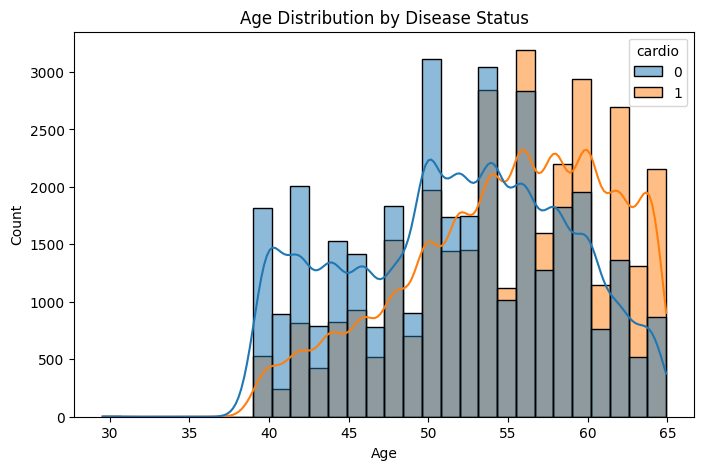

In [5]:
plt.figure(figsize=(8,5))

sns.histplot(data=df,x="age_years",hue="cardio",bins=30,kde=True)
plt.title("Age Distribution by Disease Status")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

### 📊 Age Distribution vs Cardiovascular Disease

The distribution shows a clear rightward shift for patients with cardiovascular disease, indicating that affected individuals tend to be older.

While there is some overlap between groups, disease prevalence increases noticeably after age 50, confirming age as a significant risk factor.


# Age Group VS Disease Percentage

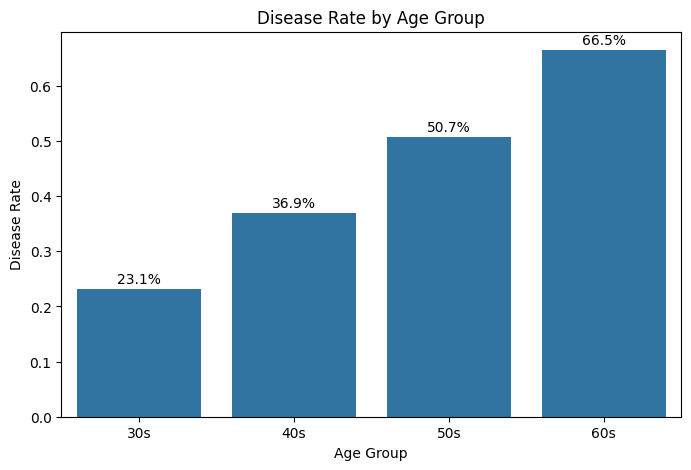

In [6]:


age_group_risk=df.groupby("age_group") ["cardio"].mean().reset_index()

plt.figure(figsize=(8,5))
ax=sns.barplot(x="age_group",y="cardio",data=age_group_risk)

for i,v in enumerate(age_group_risk["cardio"]):
    ax.text(i,v+0.01,f"{v*100 :.1f}%",ha="center")

plt.title("Disease Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Disease Rate")

plt.show()

## Disease Rate by Age Group

A strong increasing trend is observed in cardiovascular disease prevalence across age groups.
The disease rate rises from 23% in individuals in their 30s to over 66% in those aged 60 and above, indicating that the risk more than doubles with age. This confirms age as one of the most significant risk factors in the dataset.


## BLOOD PRESSURE ANALYSIS

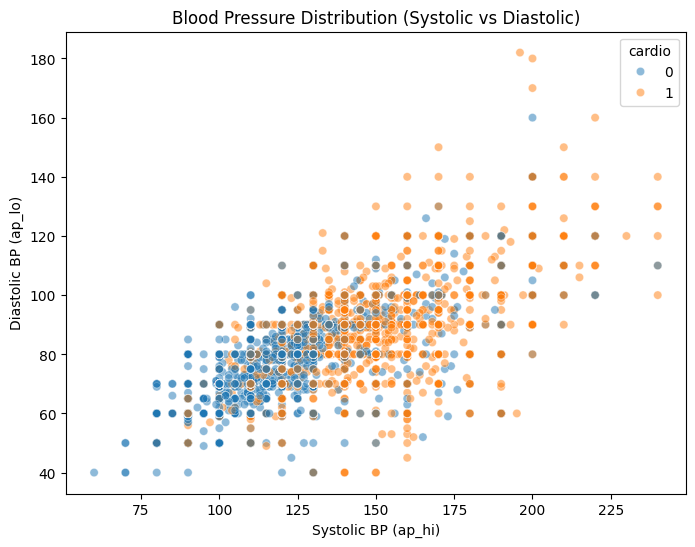

In [7]:
plt.figure(figsize=(8,6))

sns.scatterplot(x='ap_hi', y='ap_lo', hue='cardio', data=df, alpha=0.5)

plt.title("Blood Pressure Distribution (Systolic vs Diastolic)")
plt.xlabel("Systolic BP (ap_hi)")
plt.ylabel("Diastolic BP (ap_lo)")

plt.show()

## 📊 Blood Pressure vs Cardiovascular Disease
The scatter plot reveals a clear upward trend where higher systolic and diastolic blood pressure values are associated with an increased concentration of cardiovascular disease cases.

While some overlap exists, patients with elevated BP (especially above 140/90) show significantly higher disease occurrence, making blood pressure the strongest predictor among all features analyzed.

 # BMI vs Cardiovascular Disease (T test)

In [8]:
from scipy.stats import ttest_ind

bmi_yes = df[df["cardio"]==1]["BMI"]
bmi_no = df[df["cardio"]==0]["BMI"]

t_stats,p_value = ttest_ind(bmi_yes,bmi_no)

print("T-Stats:",t_stats)
print("P Value:",p_value)

T-Stats: 49.679335595697985
P Value: 0.0


In [9]:
df.groupby('cardio')['BMI'].mean()

cardio
0    26.158533
1    27.826042
Name: BMI, dtype: float64

### 📊 BMI vs Cardiovascular Disease — Insight

The average BMI of patients with cardiovascular disease (~27.82) is higher than that of non-diseased patients (~26.15).

An independent t-test shows this difference is statistically significant (p-value ≈ 0), indicating that the variation is not due to random chance.

Although the difference in mean BMI is relatively small (~1.7 units), it becomes meaningful at scale, suggesting that even moderate increases in BMI are associated with higher cardiovascular risk.


# PULSE PRESSURE ANALYSIS

Correlation: 0.3365609771552424
P Value: 0.0


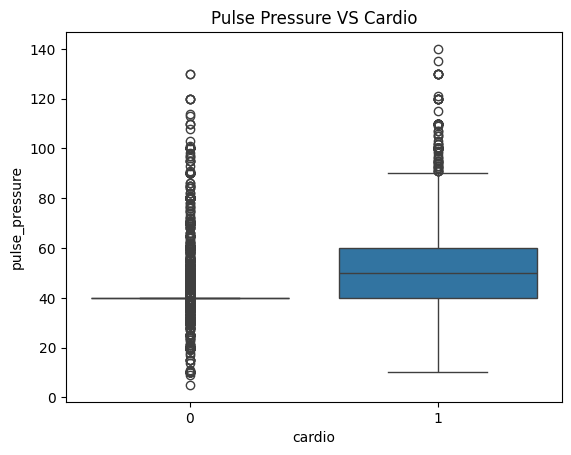

In [10]:
from scipy.stats import pointbiserialr
corr_pulse,p_pulse = pointbiserialr(df["cardio"],df["pulse_pressure"])

print("Correlation:",corr_pulse)
print("P Value:",p_pulse)


sns.boxplot(x="cardio",y="pulse_pressure",data=df)
plt.title("Pulse Pressure VS Cardio")
plt.show()



### 📊 Impact of Pulse Pressure on Cardiovascular Disease Risk

Pulse pressure shows a moderate positive relationship with cardiovascular disease (r ≈ 0.34, p < 0.05), indicating that higher pulse pressure is associated with increased disease risk.

The boxplot further confirms this trend, with the disease group showing a higher median pulse pressure compared to the non-disease group.

This suggests that not only absolute blood pressure, but also the difference between systolic and diastolic pressure is an important indicator of cardiovascular risk.

Overall, pulse pressure emerges as a strong secondary factor after systolic blood pressure.


# Chi Square Cholestrol Vs Disease Test


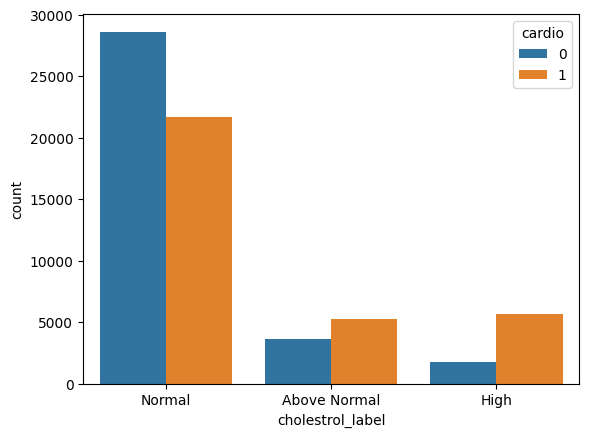

Chi2: 3230.8853089764143
P Value: 0.0


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

cont = pd.crosstab(df["cholestrol_label"],df["cardio"])
cont


order = ['Normal','Above Normal','High']
sns.countplot(x='cholestrol_label', hue='cardio', data=df,order=order)
plt.show()

chi2,p,dof,expected = chi2_contingency(cont)

print("Chi2:",chi2)
print("P Value:",p)



### 📊 Cholesterol vs Cardiovascular Disease — Insight

Chi-square test confirms a strong association between cholesterol levels and cardiovascular disease (p-value ≈ 0).

From the visualization, disease prevalence increases consistently with higher cholesterol levels. Patients with "High" cholesterol show significantly more disease cases compared to "Normal" levels.

This indicates a clear monotonic trend, suggesting cholesterol acts as one of major contributing risk factor for cardiovascular disease.


# ANNOVA TEST  to check whether the AP_High systolic BP is different for different cholestrol groups 

F stats: 1308.4849737589802
P value: 0.0


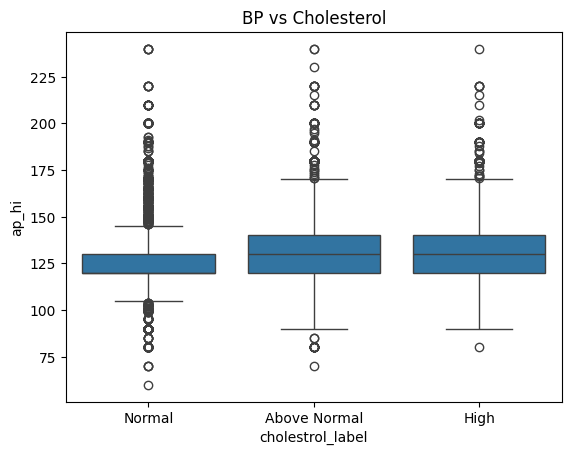

In [12]:
from scipy.stats import f_oneway

grp1 = df[df["cholesterol"]==1]["ap_hi"]
grp2 = df[df["cholesterol"]==2]["ap_hi"]
grp3 = df[df["cholesterol"]==3]["ap_hi"]


f_stats,p_value = f_oneway(grp1,grp2,grp3)
print("F stats:",f_stats)
print("P value:",p_value)

order = ['Normal','Above Normal','High']
sns.boxplot(x='cholestrol_label', y='ap_hi', data=df,order=order)
plt.title("BP vs Cholesterol")
plt.show()

### 📊 ANOVA Test — Insight

The ANOVA test shows that systolic blood pressure (ap_hi) differs significantly across cholesterol groups (p-value ≈ 0).

From the visualization, a clear increasing trend is observed where individuals with higher cholesterol levels tend to have higher systolic blood pressure.

Patients in the "High" cholesterol group show noticeably higher median BP compared to the "Normal" group, with "Above Normal" lying in between.

This indicates a strong relationship between cholesterol levels and blood pressure, suggesting that elevated cholesterol may contribute to increased cardiovascular strain.

# CORRELATION ANALYSIS 

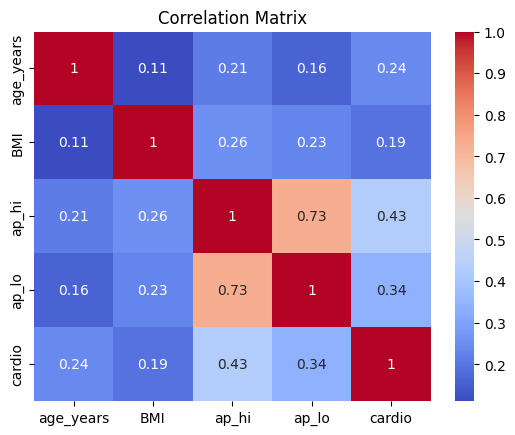

In [13]:
corr = df[['age_years','BMI','ap_hi','ap_lo','cardio']].corr()

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

### 📊 Correlation Analysis — Key Insights

Correlation analysis reveals that systolic blood pressure (ap_hi) has the strongest relationship with cardiovascular disease (correlation ≈ 0.43), making it the most influential factor among the variables analyzed.

Diastolic blood pressure (ap_lo) also shows a moderate relationship (≈ 0.34), reinforcing the importance of overall blood pressure in disease risk.

Age demonstrates a moderate positive correlation (≈ 0.24), indicating that risk increases with age, while BMI shows a relatively weaker but still positive relationship (≈ 0.19).

Additionally, a strong correlation exists between systolic and diastolic blood pressure (≈ 0.73), suggesting that both measurements tend to increase together.

Overall, the analysis highlights blood pressure as the primary driver of cardiovascular disease risk, followed by age and BMI.


# SHAPIRO TEST TO JUST CHECK NORMAL DISTRIBUTION FOR ACCUURACY

In [14]:
from scipy.stats import shapiro

bmi_sample = df["BMI"].sample(5000)
age_sample = df["age_years"].sample(5000)
bp_sample = df["ap_hi"].sample(5000)

print("BMI:", shapiro(bmi_sample))
print("Age:", shapiro(age_sample))
print("BP:", shapiro(bp_sample))

BMI: ShapiroResult(statistic=np.float64(0.9722627527641845), pvalue=np.float64(4.4561987467593694e-30))
Age: ShapiroResult(statistic=np.float64(0.9641353224171467), pvalue=np.float64(1.6089930228578235e-33))
BP: ShapiroResult(statistic=np.float64(0.9144651962728944), pvalue=np.float64(1.2853601227548139e-46))


### 📊 Normality Check — Shapiro-Wilk Test

Shapiro-Wilk test was applied on BMI, age, and systolic blood pressure (ap_hi) to assess normality.

All variables showed p-values significantly less than 0.05, indicating that the data does not follow a normal distribution.

However, given the large sample size, the Central Limit Theorem allows the use of parametric tests such as T-test and ANOVA without significant impact on results.


# “Relationship between Age, BP & BMI and Cardiovascular Disease”

Correlation: 0.24136689509207288
P value: 0.0
Correlation: 0.4281562797301902
P value: 0.0
Correlation: 0.18897127455173449
P value: 0.0


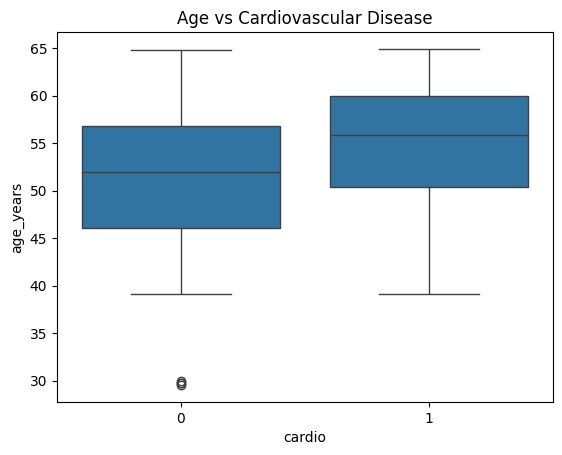

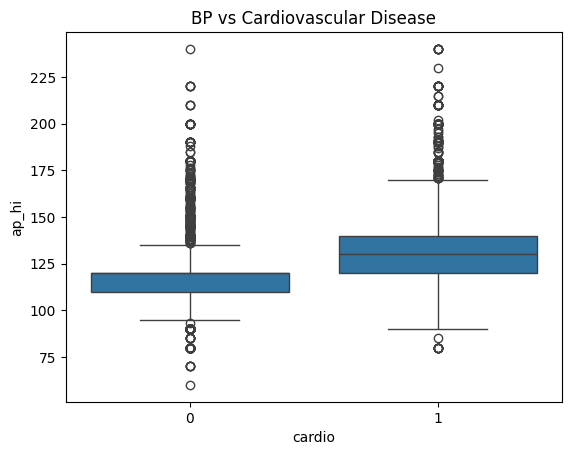

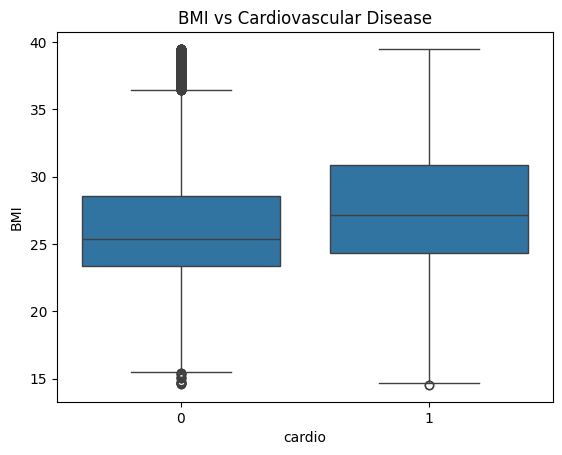

In [15]:
from scipy.stats import pointbiserialr

corr_age,p_age = pointbiserialr(df["cardio"],df["age_years"])

print("Correlation:",corr_age)
print("P value:",p_age)


corr_bp,p_bp = pointbiserialr(df["cardio"],df["ap_hi"])

print("Correlation:",corr_bp)
print("P value:",p_bp)

corr_bmi,p_bmi = pointbiserialr(df["cardio"],df["BMI"])

print("Correlation:",corr_bmi)
print("P value:",p_bmi)

sns.boxplot(x='cardio', y='age_years', data=df)
plt.title("Age vs Cardiovascular Disease")
plt.show()

sns.boxplot(x='cardio', y='ap_hi', data=df)
plt.title("BP vs Cardiovascular Disease")
plt.show()

sns.boxplot(x='cardio', y='BMI', data=df)
plt.title("BMI vs Cardiovascular Disease")
plt.show()

### 📊 Relationship between Age, Blood Pressure, BMI and Cardiovascular Disease --- Insights

Point-biserial correlation analysis shows that systolic blood pressure (ap_hi) has the strongest relationship with cardiovascular disease (r ≈ 0.43), making it the most influential factor among the variables analyzed.

Age also demonstrates a moderate positive relationship (r ≈ 0.24), indicating that the risk of cardiovascular disease increases with age.

BMI shows a weaker but still positive relationship (r ≈ 0.19), suggesting that higher body mass contributes to disease risk, though its impact is lower compared to blood pressure and age.

All relationships are statistically significant (p < 0.05), confirming that these factors are meaningfully associated with cardiovascular disease.

Overall, the analysis highlights blood pressure as the primary driver, followed by age and BMI as secondary contributing factors.


# Life Style impact on Disease

Smoking p-value: 7.927754436556232e-05
Alcohol p-value: 0.01892255903177954
Activity p-value: 9.26254028950725e-21

 smoke_label
Non-Smoker    0.491287
Smoker        0.464364
Name: cardio, dtype: float64

 alco_label
Alcohol       0.469595
No Alcohol    0.489975
Name: cardio, dtype: float64

 active_label
Active      0.479954
Inactive    0.525602
Name: cardio, dtype: float64


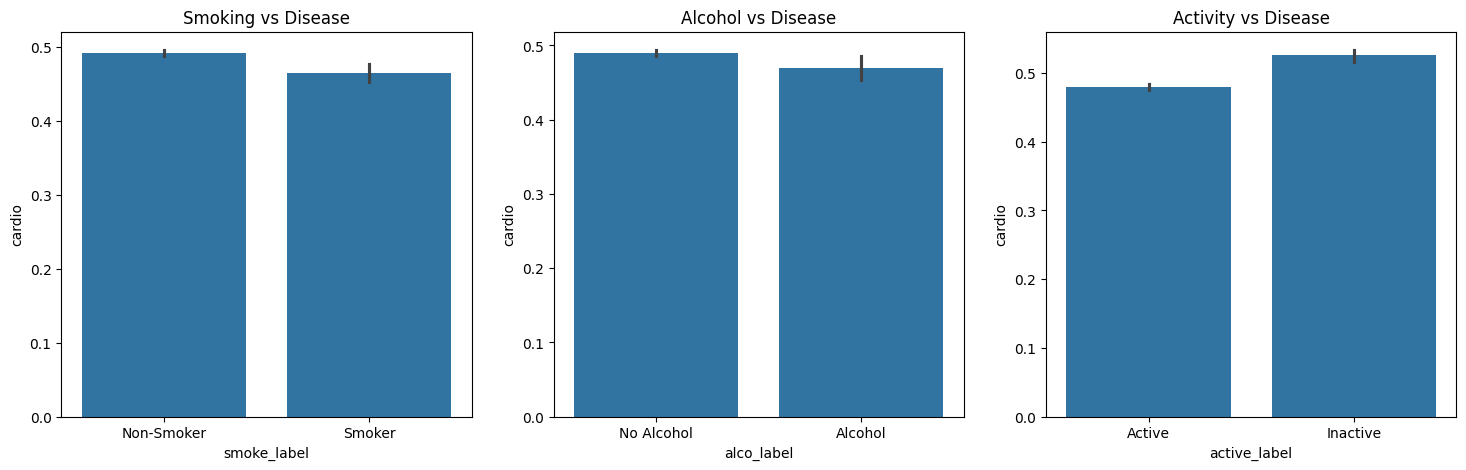

In [16]:
from scipy.stats import chi2_contingency

# smoking
cont_smoke = pd.crosstab(df['smoke_label'], df['cardio'])
chi2, p, _, _ = chi2_contingency(cont_smoke)
print("Smoking p-value:", p)

# alcohol
cont_alco = pd.crosstab(df['alco_label'], df['cardio'])
chi2, p, _, _ = chi2_contingency(cont_alco)
print("Alcohol p-value:", p)

#activity
cont_act = pd.crosstab(df['active_label'],df['cardio'])
chi2,p,_,_ = chi2_contingency(cont_act)
print("Activity p-value:",p)

lifestyle = ["smoke_label","alco_label","active_label"]

for col in lifestyle:
    print("\n",df.groupby(col)["cardio"].mean())

#Visualizations

fig,axes = plt.subplots(1,3,figsize=(18,5))

sns.barplot(x="smoke_label",y="cardio",data=df,ax=axes[0])
axes[0].set_title("Smoking vs Disease")

sns.barplot(x="alco_label",y="cardio",data=df,ax=axes[1])
axes[1].set_title("Alcohol vs Disease")


sns.barplot(x="active_label",y="cardio",data=df,ax=axes[2])
axes[2].set_title("Activity vs Disease")
plt.show()

### 📊 Lifestyle Factors vs Cardiovascular Disease — Deep Analysis

Smoking and alcohol consumption show statistically significant relationships with cardiovascular disease; however, the actual difference in disease rates between groups is minimal and inconsistent, indicating weak practical impact.

In contrast, physical activity demonstrates both statistical and practical significance. Inactive individuals show a noticeably higher disease rate compared to active individuals, highlighting physical inactivity as a key modifiable risk factor.

The results suggest that while smoking and alcohol may appear statistically relevant, their effect is likely influenced by confounding factors, whereas physical activity shows a clear and meaningful relationship with cardiovascular disease risk.


# Final Summary

### This analysis identifies the key factors influencing cardiovascular disease using exploratory data analysis and statistical testing.

### Blood pressure emerges as the strongest predictor of cardiovascular disease. Both systolic and diastolic blood pressure show a clear and consistent increase in disease prevalence, making BP the most critical risk factor.

###  Age is another major contributor, with disease rates rising sharply across age groups. Individuals above 50 show significantly higher risk, confirming age as a strong non-modifiable factor.

### BMI has a moderate impact on cardiovascular risk. Although the difference in average BMI between diseased and non-diseased individuals is relatively small, it becomes meaningful at scale, indicating that higher BMI contributes to increased risk.

### Pulse pressure also shows a moderate positive relationship with disease, highlighting that the difference between systolic and diastolic pressure is an important secondary indicator.

### Cholesterol levels are strongly associated with both blood pressure and disease prevalence. Higher cholesterol groups consistently show elevated blood pressure, reinforcing its indirect role in cardiovascular risk.

### Among lifestyle factors, physical activity stands out as a key protective factor. Inactive individuals have noticeably higher disease rates compared to active individuals. In contrast, smoking and alcohol show statistical significance but weak practical impact in this dataset.

### Overall, the analysis highlights that cardiovascular disease risk is primarily driven by physiological factors such as blood pressure and age, followed by BMI and lifestyle behaviors. Improving physical activity and managing blood pressure can significantly reduce risk.